# One House Example

## Setup

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import scipy.stats
from pathlib import Path

cwd = Path.cwd()  # Set cwd to Code folder

plot_folder = cwd.parent/'Plots/One_House_Example'

## Forward Model

index 1 Corresponds to a single house, index 0 Corresponds to the substation

Using $I_{1,0} = \dfrac{V_{0} - V_{1}}{\sigma_{1,0}L_{1,0}}$ and $P_{1} = V_{1}I_{1,0}$ we get:

$P_{1} = \dfrac{V_{1}(V_{0} - V_{1})}{\sigma_{1,0}L_{1,0}}$, which leads to

$V_{1} = \dfrac{V_{0} + \sqrt{V^{2}_{0} - \sigma_{1,0}L_{1,0}P_{1}}}{2}$. We Discard negative root as it's the unstable region.

Where $\sigma_{1,0}$ is the wire resistance between house and substation, $L_{1,0}$ is the length between house and substation, $I_{1,0}$ is the current between house and substation

$P_{1}$ is unknown but is modelled from an underlying distribution

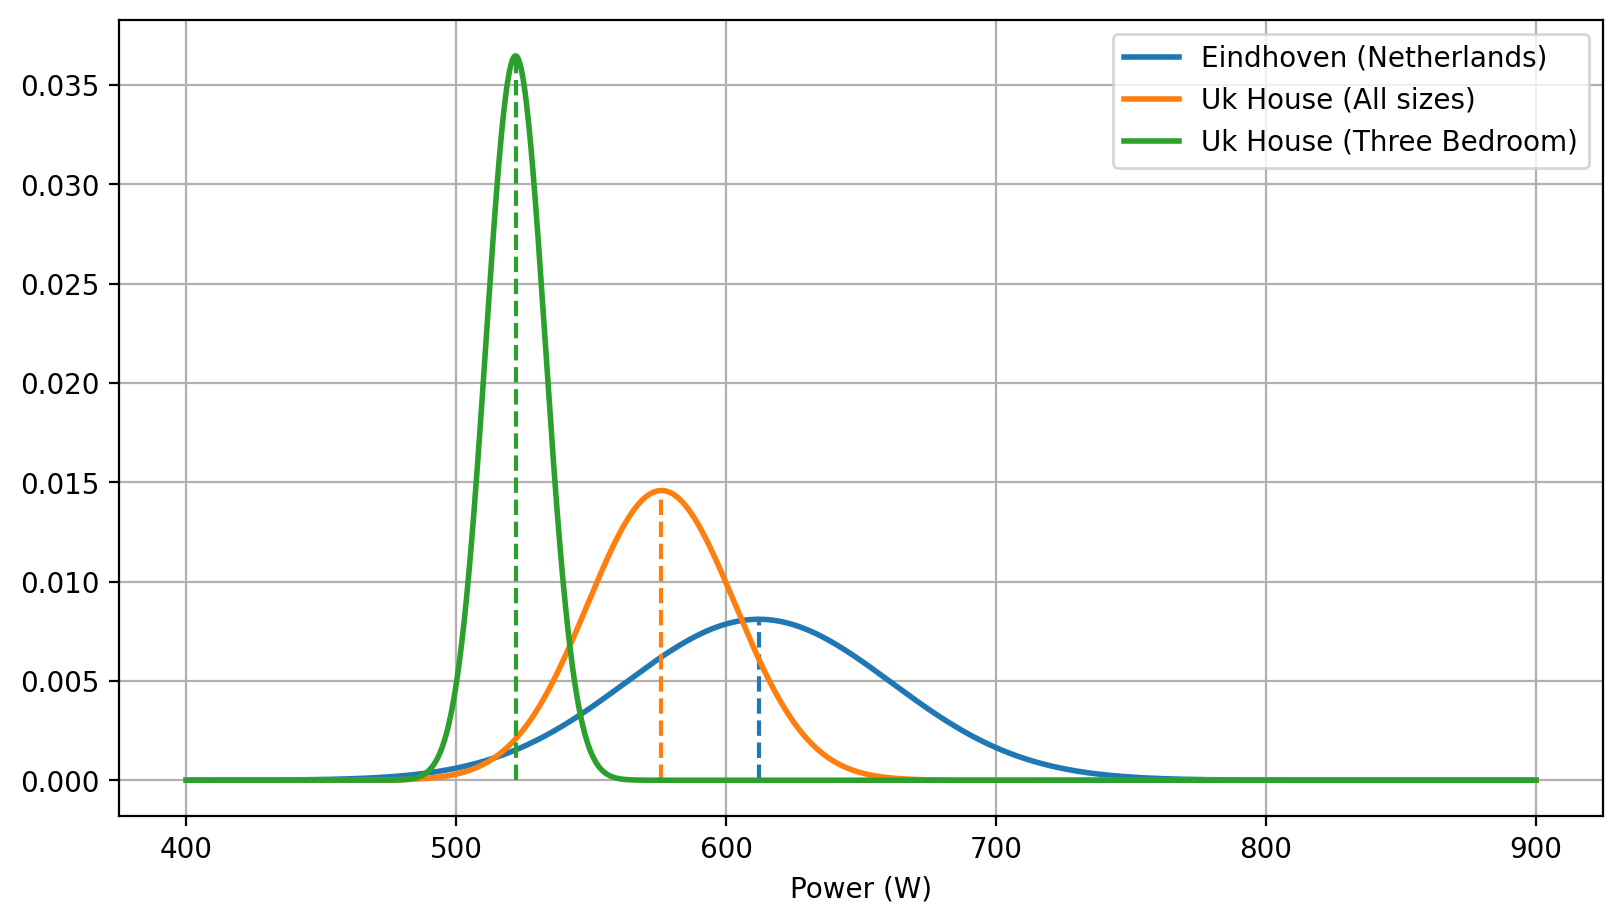

In [ ]:
# Power distributions

b_list = np.array([4.3, 3.7, 3.1])  # Values in MW
b_list *= 1e6 * 0.18/1000 # Values in W

a_list = np.array([2.5, 2.7, 2.7])  # Values in MW
a_list *= 1e6 * 0.18/1000 # Values in W

seed = 142536

labels = ['Eindhoven (Netherlands)', 'Uk House (All sizes)', 'Uk House (Three Bedroom)']
colors = ['C0', 'C1', 'C2']

distribution_list = []

# Creating distributions
for a, b, in zip(a_list, b_list):
    mean = (a + b)/2
    std = (b - a)/(2 * 3.29)

    P_dist = scipy.stats.norm(loc=mean, scale=std)
    distribution_list.append(P_dist)

x = np.linspace(400, 900, int(1e5))
fig, ax = plt.subplots(figsize=(8, 4.5), layout='constrained', dpi=200)

for distribution, label, color in zip(distribution_list, labels, colors):
    ax.plot(x, distribution.pdf(x), lw=2, label=label)
    ax.vlines(distribution.mean(), distribution.pdf(x).min(), distribution.pdf(x).max(), color=color, ls='--')

ax.set_xlabel('Power (W)')
ax.grid()
ax.legend()
plt.savefig(plot_folder/'power_distribution.pdf')
plt.show()

In [3]:
v0 = 240  # Sub-station Voltage (Volts) 
sigma = 0.397/1000  # Wire resistance (ohms/metre) 
L = 20  # Cable length (metres) (ground truth value)
num_samples = 100

# Array to store voltages
v1_array = np.zeros((len(distribution_list), num_samples))  # House voltages (Volts)

def forward(v0, sigma, L, num_samples, distribution : scipy.stats._distn_infrastructure.rv_continuous_frozen):
      P = distribution.rvs(size=num_samples, random_state=seed)  # Power (Watts)
      v1 = (v0 + np.sqrt(v0**2 - 4 * sigma * L * P))/2  # House Voltage

      return v1

# generating 100 different samples for each distribution at a specified ground truth length
for i, distribution in enumerate(distribution_list):
      v1_array[i] = forward(v0, sigma, L, num_samples=num_samples, distribution=distribution)


## Length distribution (Backward model)

Rearaging equation for $P_{1}$ in forward model for $L_{1,0}$, we get

$L_{1,0} = \dfrac{V_{1}(V_{0} - V_{1})}{\sigma_{1,0}P_{1}}$. 

Where $V_{0}$, $V_{1}$ are the known substation and house volatages, $P_{1}$ is the unknown power at the house but is modelled to be following a distribution

In [4]:
def backward(v0, v1, sigma, num_samples, distribution : scipy.stats._distn_infrastructure.rv_continuous_frozen):
      P = distribution.rvs(size=num_samples, random_state=seed)  # Power (Watts)
      L_dist = v1 * (v0 - v1)/(sigma * P)  # Length distribution

      return L_dist

# Array to store estimated lengths
estimated_L_list = np.zeros_like(v1_array)

# Looping through samples
for i in range(num_samples):
      v1_list = v1_array[:,i]  # slice for a sample with each distribution voltage value
      fig, ax = plt.subplots(figsize=(8, 4.5), layout='constrained', dpi=200)
      
      # Looping through distributions and voltages
      for j, (v1, distribution, label, color) in enumerate(zip(v1_list, distribution_list, labels, colors)):

            # Apply backward model to find length distribution
            L_dist = backward(v0, v1, sigma, num_samples=int(1e5), distribution=distribution)

            bin_width = 0.1
            bins = np.arange(L_dist.min(), L_dist.max() + bin_width, bin_width)

            # Obtain frequency conuts
            counts, _, _ = ax.hist(L_dist, bins=bins, label=label, alpha=0.75)

            # Find highest frequency bin
            pos = np.argmax(counts)

            # Find length midpoint for that bin as estimated length
            length = bins[pos] + bin_width/2
            ax.axvline(length, color=color, ls='--', zorder=4, label=label +'\nestimated wire length')  # Add estimated length to graph
            
            estimated_L_list[j,i] = length

      ax.set_xlabel('Length (m)')
      ax.set_ylabel('Frequency')

      #bins_inset = np.arange(L-10, L+10+bin_width, 0.5)
      #ax_inset = ax.inset_axes((0.6, 0.6, 0.35, 0.35))
      #ax_inset.hist(L_dist, bins=bins_inset)
      #zoom_region = ax.indicate_inset(inset_ax=ax_inset, edgecolor='black', lw=1, ls='--', alpha=1)
      
      #for connector in zoom_region.connectors[:2]:
      #      connector.set_visible(True)

      ax.axvline(L, color='black', ls='--', label='Ground truth wire length')  # Add ground truth length to graph
      #ax_inset.axvline(L, color='black', ls='-.')

      ax.grid()
      ax.legend()

      plt.savefig(plot_folder/f'length_distribution_{i+1}.pdf')
      plt.close()

## Error Calculations

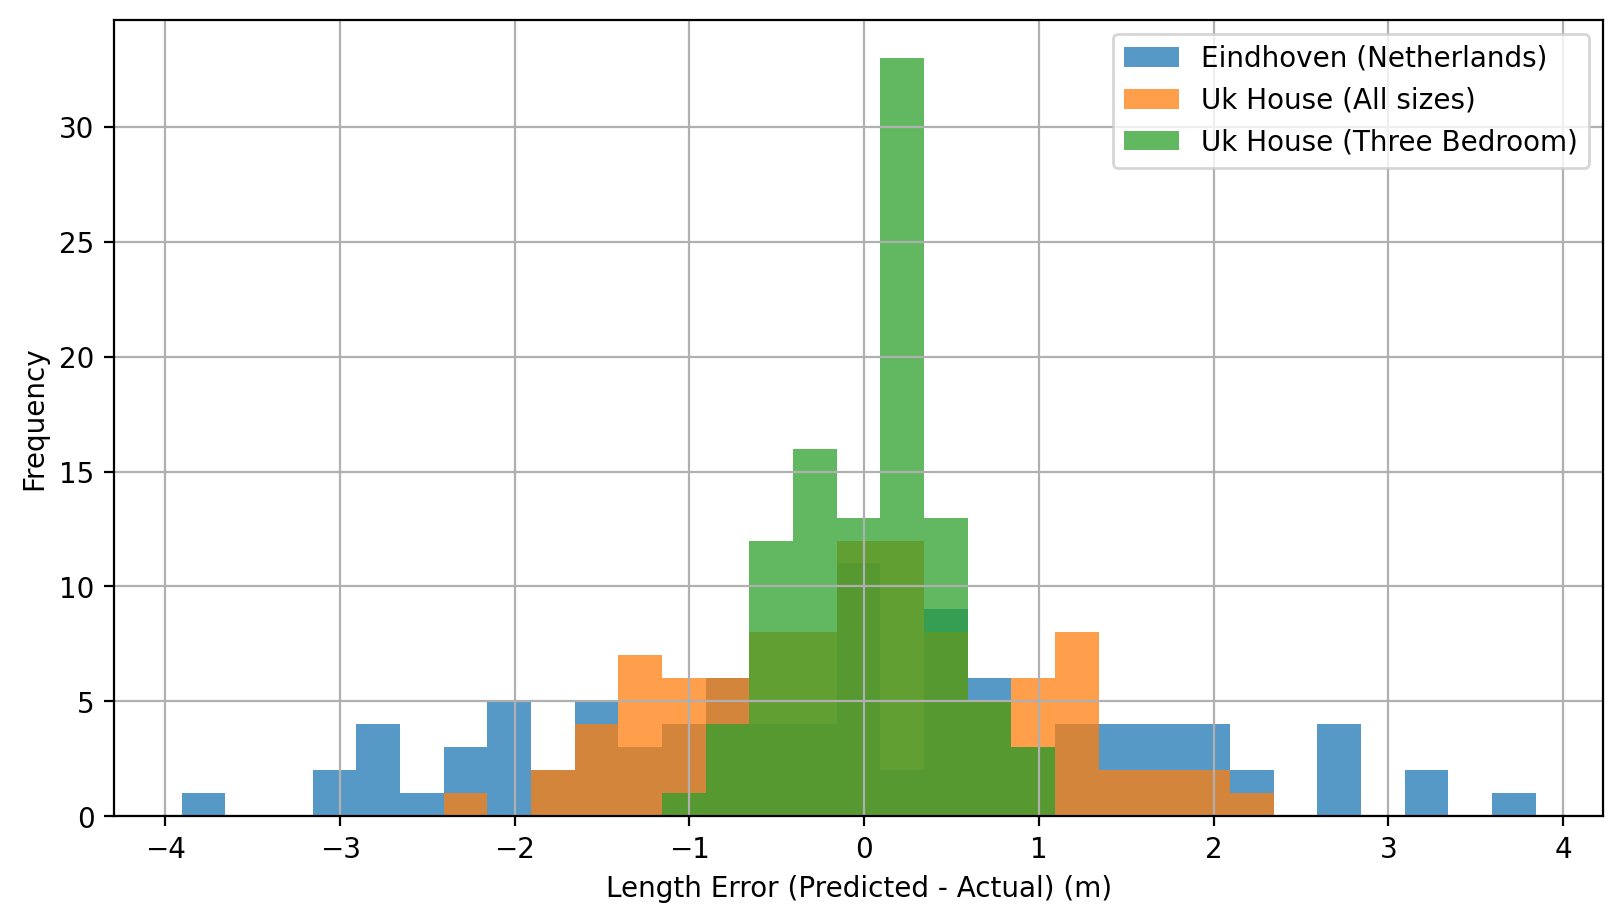

In [6]:
errors = estimated_L_list - L  # Take known length away from estimations

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=200, layout='constrained')

bin_width = 0.25
bins = np.arange(errors.min(), errors.max() + bin_width, bin_width)

# loop through error array rows corresponding to different distributions 
for row, label in zip(errors, labels):
    ax.hist(row, bins=bins, label=label, alpha=0.75)

ax.set_xlabel('Length Error (Predicted - Actual) (m)')
ax.set_ylabel('Frequency')
ax.grid()
ax.legend()

plt.savefig(plot_folder/'error_plot.pdf')
plt.show()